James Zeiger    |   Signal Processing exam

To begin, we can observe that the data is recorded every 15minutes and the time format is in 24hours.

# 1. What is the channel of the recordings?
The channel of these recordings is electrical. Electricity flows in and out of the buildings and these inputs and outputs are recorded every 15minutes, so it is a non-continuous signal (like a sine wave).

In [2]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import math

In [3]:
# Load the CSV file
csv_file = "dataset-siginf-cc-2026.csv"
data = pd.read_csv(csv_file)
print(data)

           time  power import building 1 [watts]  \
0      00:00:00                       280.385475   
1      00:15:00                       280.631285   
2      00:30:00                       609.050279   
3      00:45:00                       316.078212   
4      01:00:00                       314.357542   
...         ...                              ...   
35131  22:45:00                       312.983240   
35132  23:00:00                       312.905028   
35133  23:15:00                       312.307263   
35134  23:30:00                       312.899441   
35135  23:45:00                       306.363128   

       power export building 1 [watts]  power import building 2 [watts]  \
0                                  0.0                      1830.256983   
1                                  0.0                      2543.480447   
2                                  0.0                      2393.027778   
3                                  0.0                       334.661111   


We can observe 35136 rows and since each row is seperated by 15minutes, then this experiment lasted:

35136/15 = 2342.4 minutes = 39.04 hours = 1.62 days.

Every 6 hours corresponds to 5400 Time score on the graphs represented by the vertical bars (ClaudeAI).

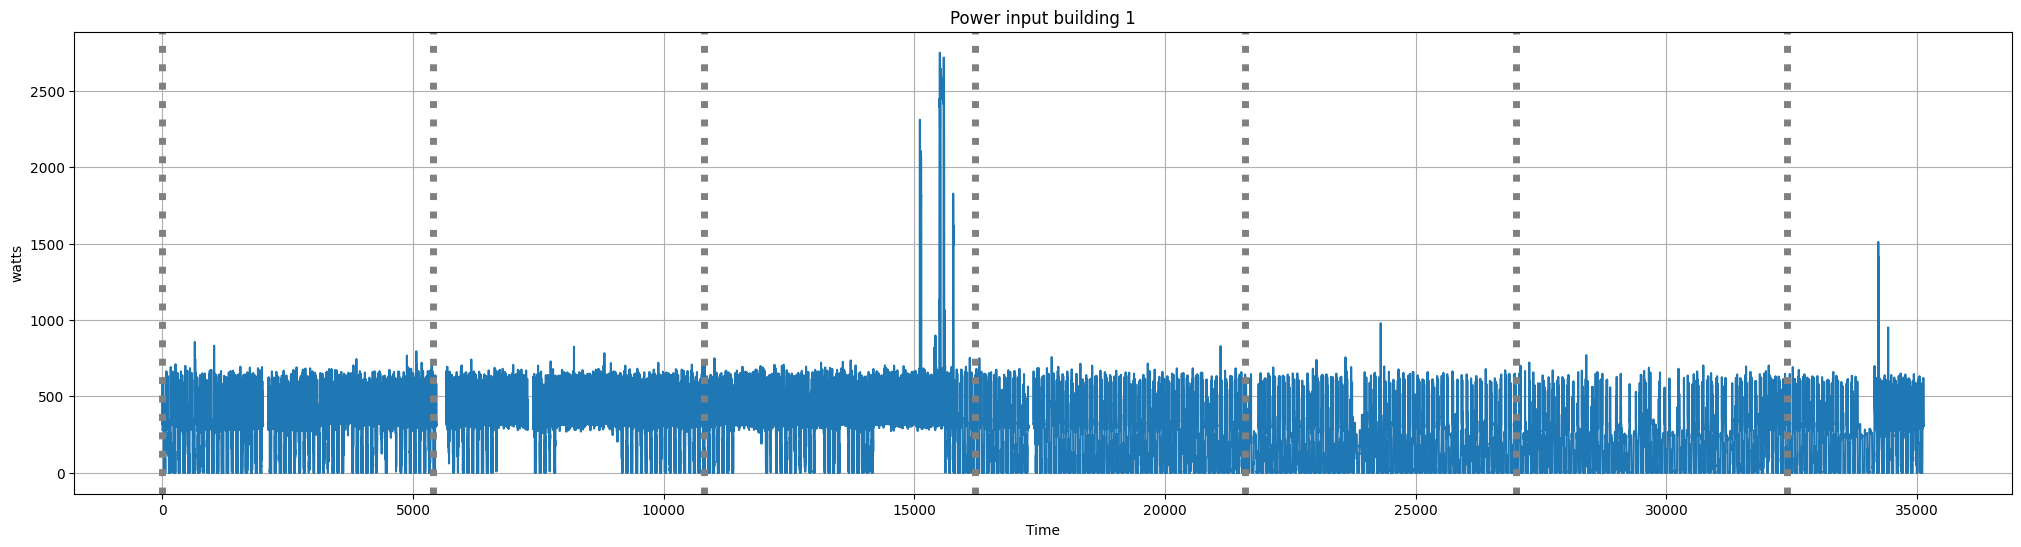

In [4]:
ib1 = data["power import building 1 [watts]"]

plt.figure(figsize=(25, 6))
plt.plot(ib1)
plt.xlabel("Time")
# plt.xticks(rotation='vertical')
plt.ylabel("watts")
plt.title("Power input building 1")
plt.grid()
for x in range(0, len(ib1), 5400):
    plt.axvline(x=x, color='gray', linestyle=':', linewidth=5)
plt.show()

# 2. What is the dimensionality of the signal?
As we can see here, each signal has only one dimension which is the amount of watts. It's position in the one-dimensional array is the time.

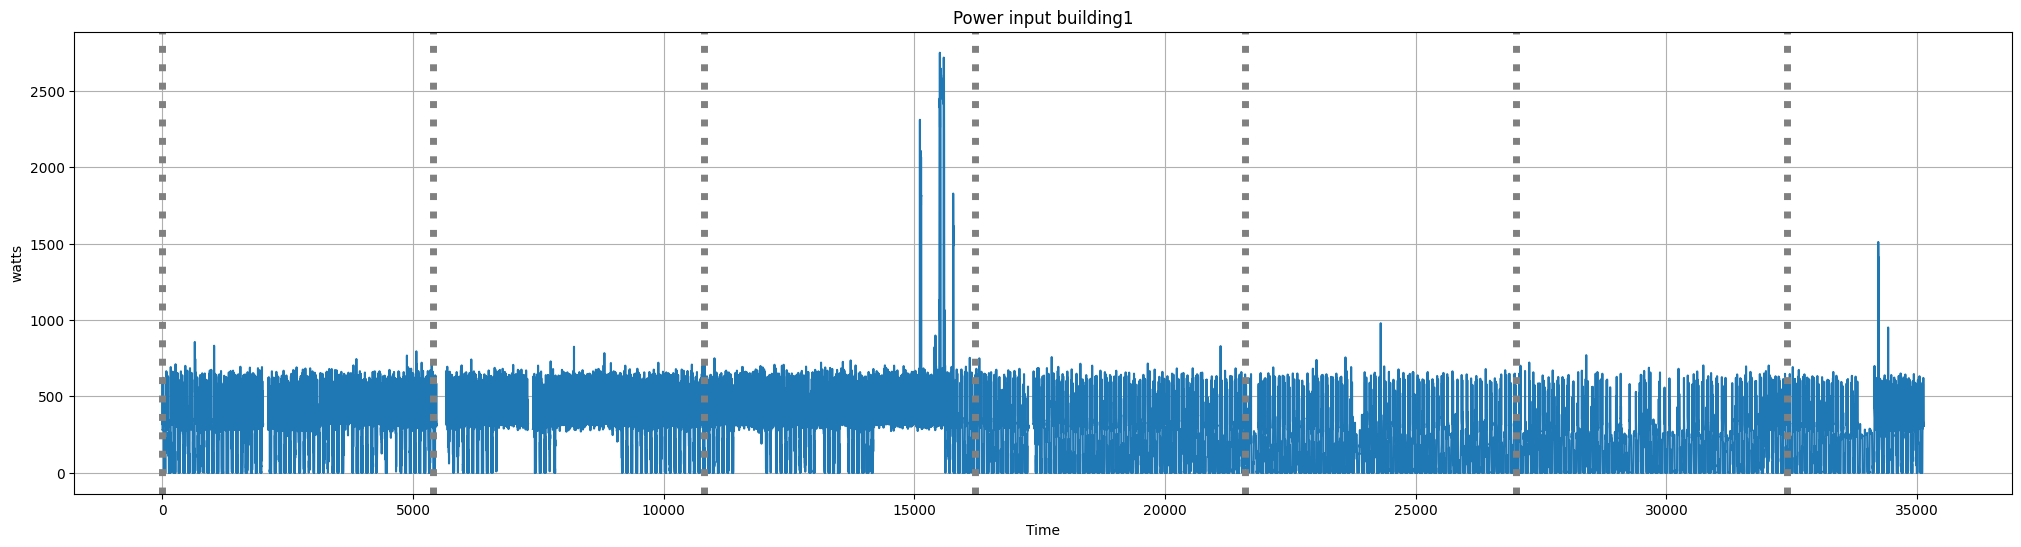

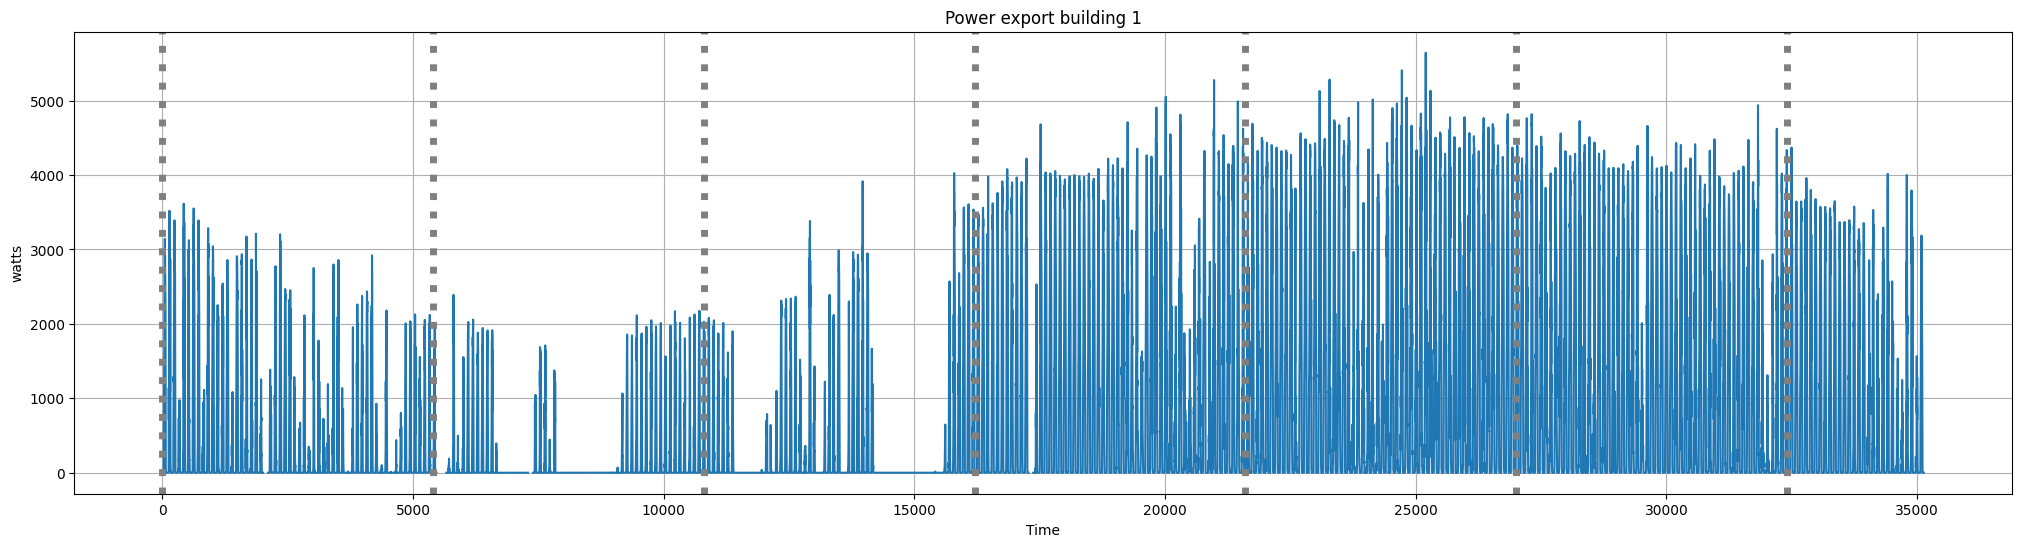

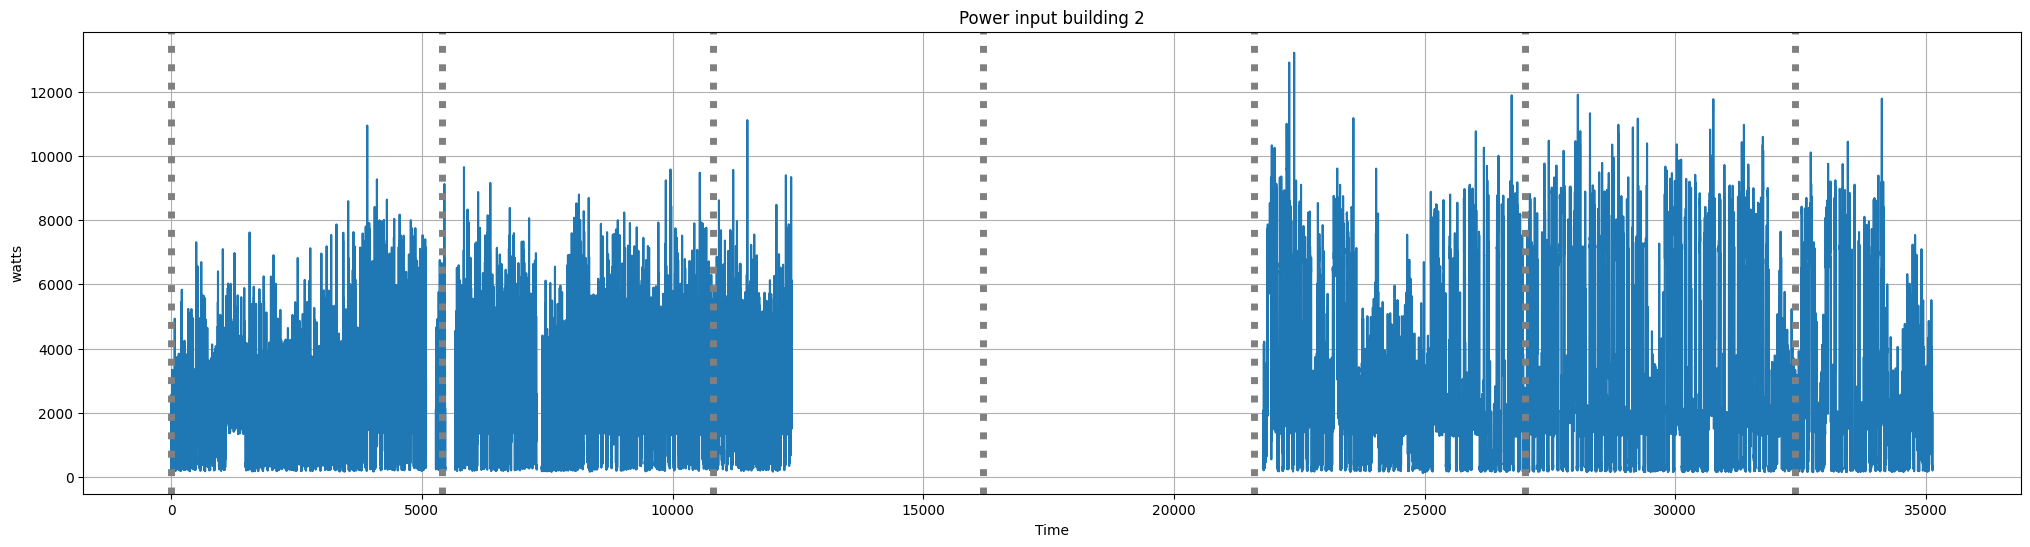

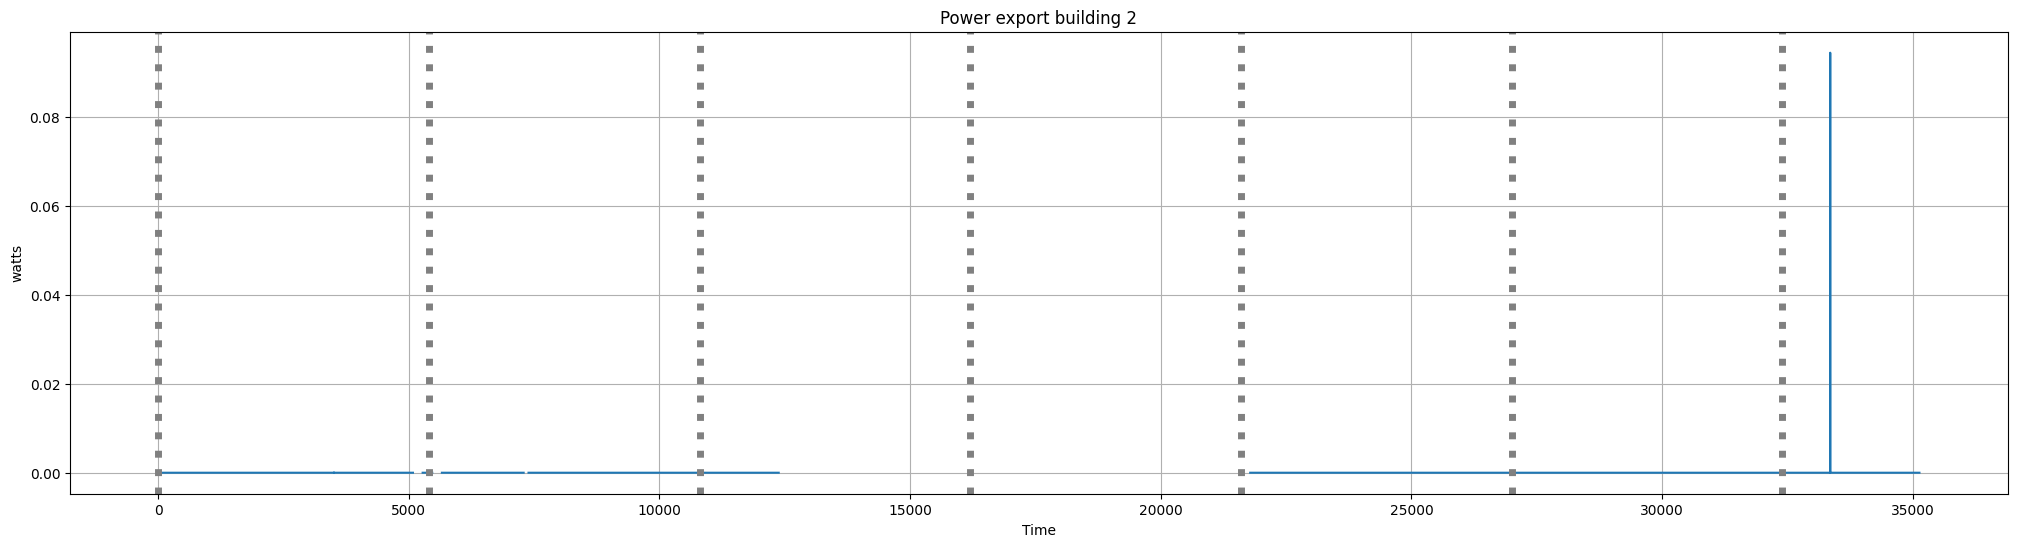

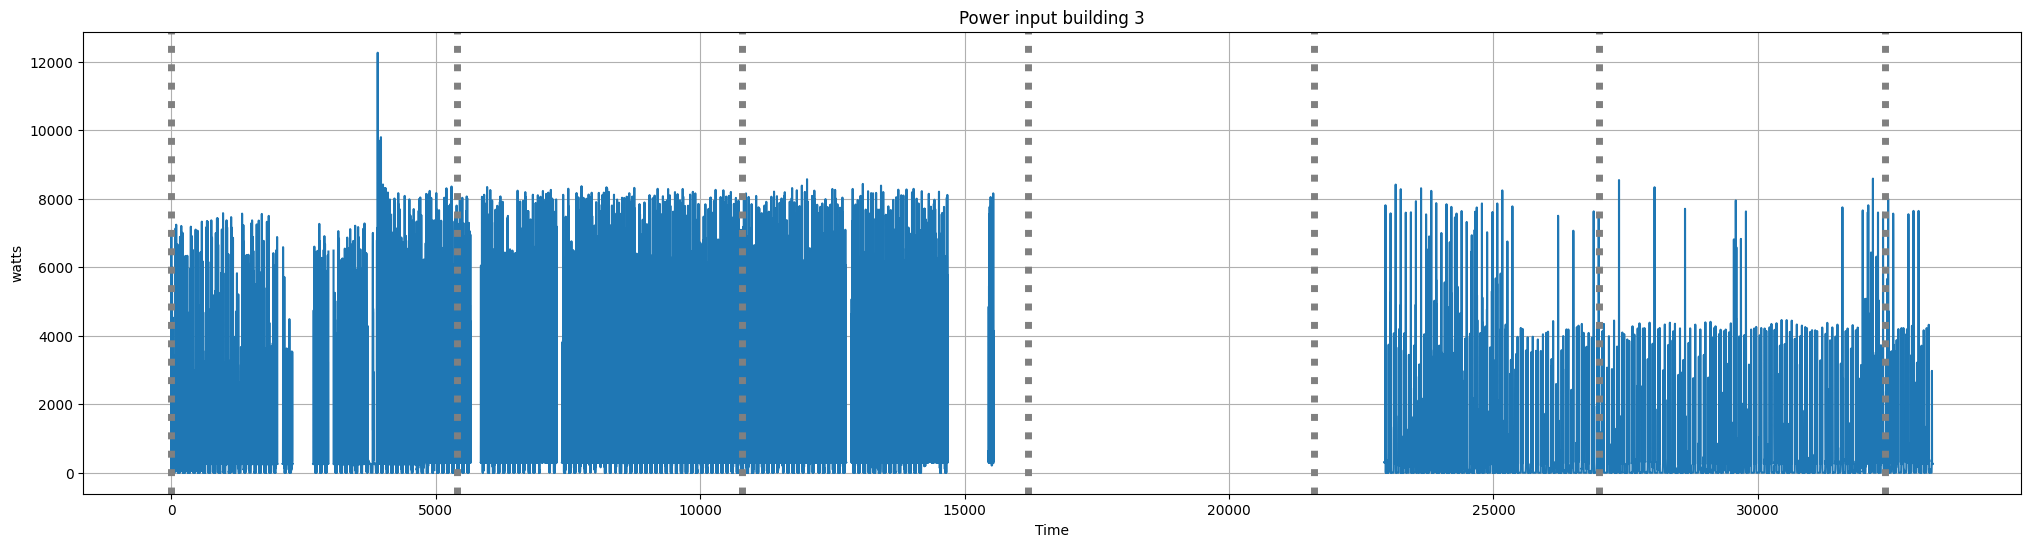

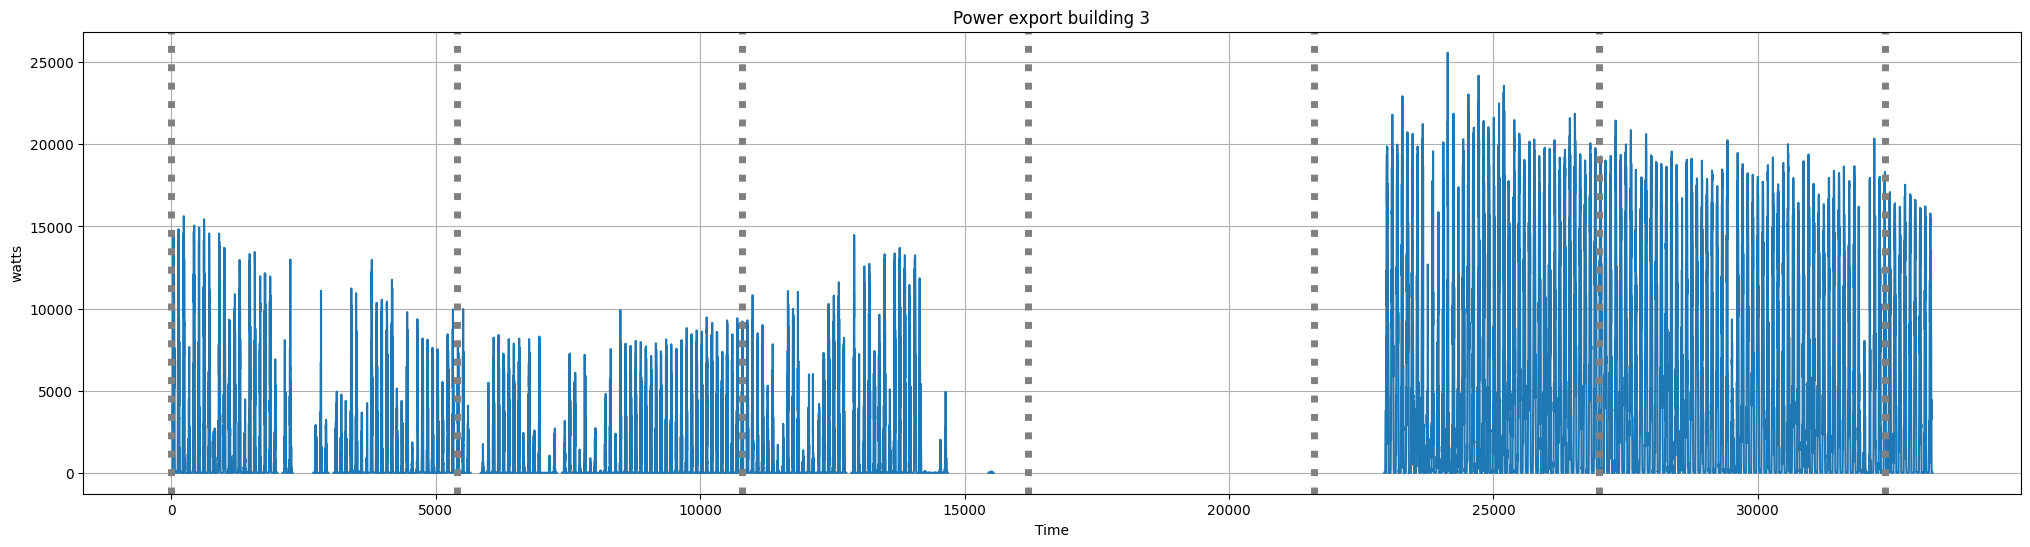

In [5]:
ib1 = data["power import building 1 [watts]"]

plt.figure(figsize=(25, 6))
plt.plot(ib1)
plt.xlabel("Time")
# plt.xticks(rotation='vertical')
plt.ylabel("watts")
plt.title("Power input building1")
plt.grid()
for x in range(0, len(ib1), 5400):
    plt.axvline(x=x, color='gray', linestyle=':', linewidth=5)
plt.show()

eb1 = data["power export building 1 [watts]"]

plt.figure(figsize=(25, 6))
plt.plot(eb1)
plt.xlabel("Time")
# plt.xticks(rotation='vertical')
plt.ylabel("watts")
plt.title("Power export building 1")
plt.grid()
for x in range(0, len(ib1), 5400):
    plt.axvline(x=x, color='gray', linestyle=':', linewidth=5)
plt.show()

ib2 = data["power import building 2 [watts]"]

plt.figure(figsize=(25, 6))
plt.plot(ib2)
plt.xlabel("Time")
# plt.xticks(rotation='vertical')
plt.ylabel("watts")
plt.title("Power input building 2")
plt.grid()
for x in range(0, len(ib1), 5400):
    plt.axvline(x=x, color='gray', linestyle=':', linewidth=5)
plt.show()

eb2 = data["power export building 2 [watts]"]

plt.figure(figsize=(25, 6))
plt.plot(eb2)
plt.xlabel("Time")
# plt.xticks(rotation='vertical')
plt.ylabel("watts")
plt.title("Power export building 2")
plt.grid()
for x in range(0, len(ib1), 5400):
    plt.axvline(x=x, color='gray', linestyle=':', linewidth=5)
plt.show()

ib3 = data["power import building 3 [watts]"]

plt.figure(figsize=(25, 6))
plt.plot(ib3)
plt.xlabel("Time")
# plt.xticks(rotation='vertical')
plt.ylabel("watts")
plt.title("Power input building 3")
plt.grid()
for x in range(0, len(ib1), 5400):
    plt.axvline(x=x, color='gray', linestyle=':', linewidth=5)
plt.show()

eb3 = data["power export building 3 [watts]"]

plt.figure(figsize=(25, 6))
plt.plot(eb3)
plt.xlabel("Time")
# plt.xticks(rotation='vertical')
plt.ylabel("watts")
plt.title("Power export building 3")
plt.grid()
for x in range(0, len(ib1), 5400):
    plt.axvline(x=x, color='gray', linestyle=':', linewidth=5)
plt.show()

As an interesting remark, the mesures starting taking place at midnight. 6 o'clock in the morning represents the second bar on the graphs.

# 3. What are the possible source of noise and how can I filter them?
As we can observe, there are no building power reports that do not contain any data holes. This is where there is data being recorded and abruptly stops.

This can be due to many reasons like:
- Power cuts (power failure)
- Mesurement utensils failure

This is one of the many signal processing and data analysis problems.

Another is noise on a signal. In the case of electrical signals, noise can be introduced into the signal as a result of:
- Cable wear
- Interferance with other electrical currents

Potential fixes to this issue would be:
### Signal smoothing
#### Least square error
We can do this in the time domain, with no need to switch to the frequency domain, as it is applied on the watt values themselves.
$$min_{x'}\sum_{k=1}^{T}(x[k]-x'[k])^2$$

Where x[k] is the watt value at time k.
#### Sliding average
Takes a point's neighbours in order to correct any anormalities, by convolutating two signals (normal signal and a kernel). Here it is important to use the Fournier Transform, as convolution in the time domain become a multiplication in the frequency domain.

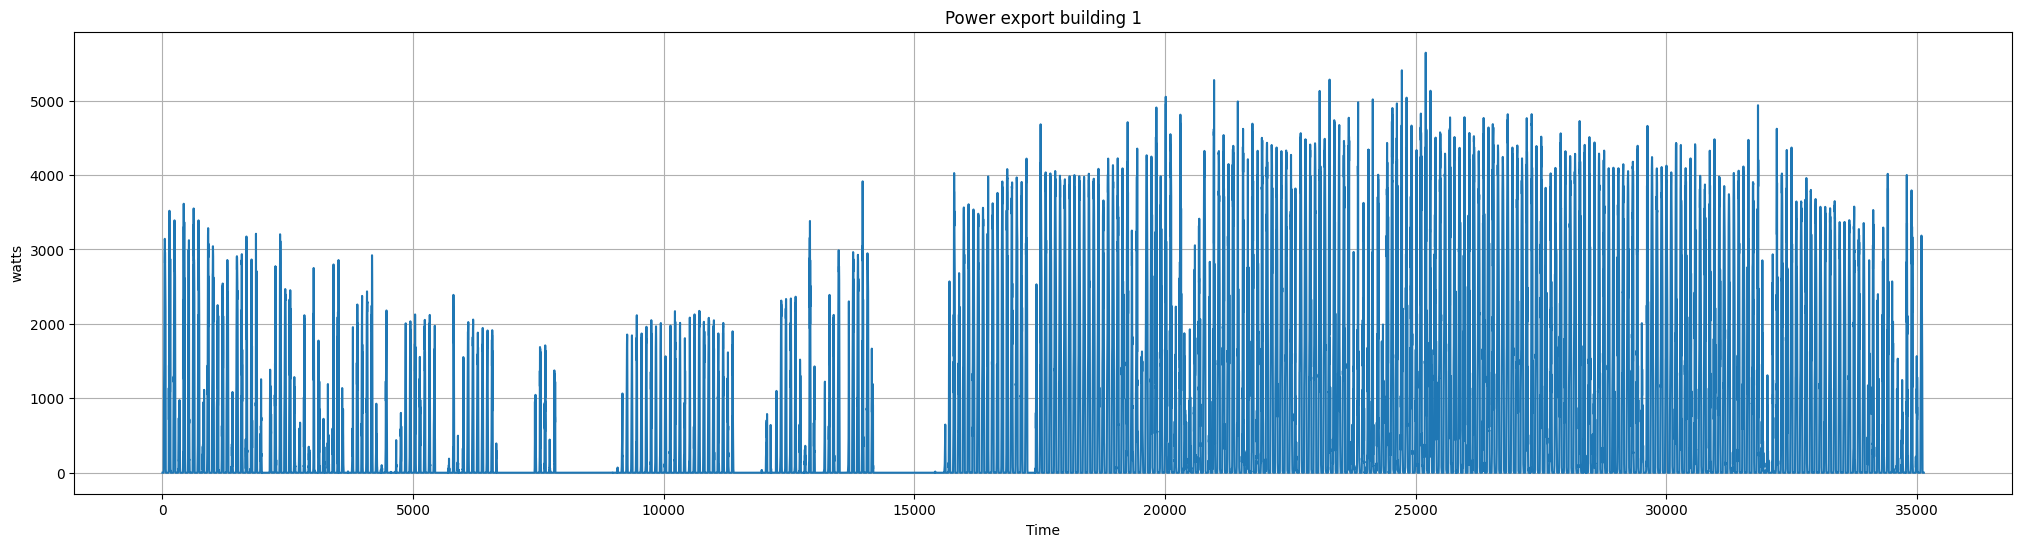

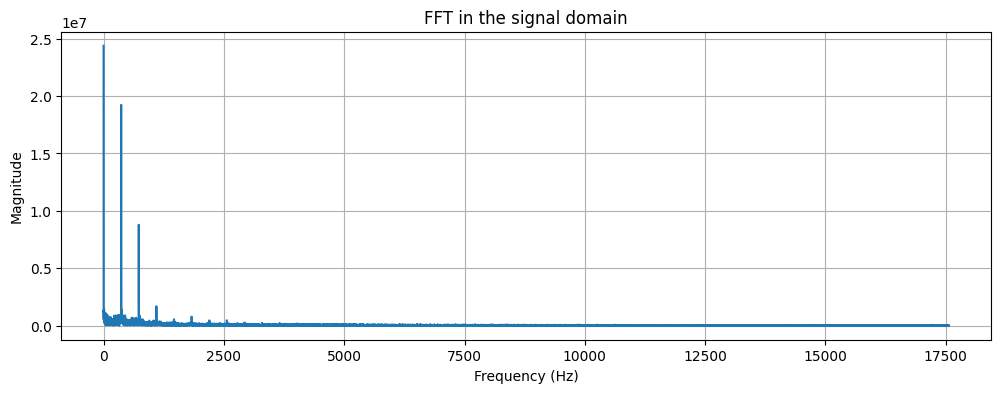

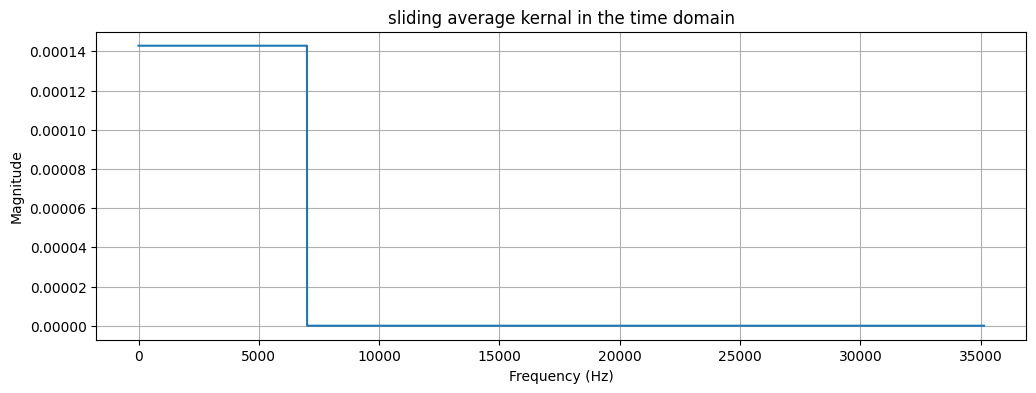

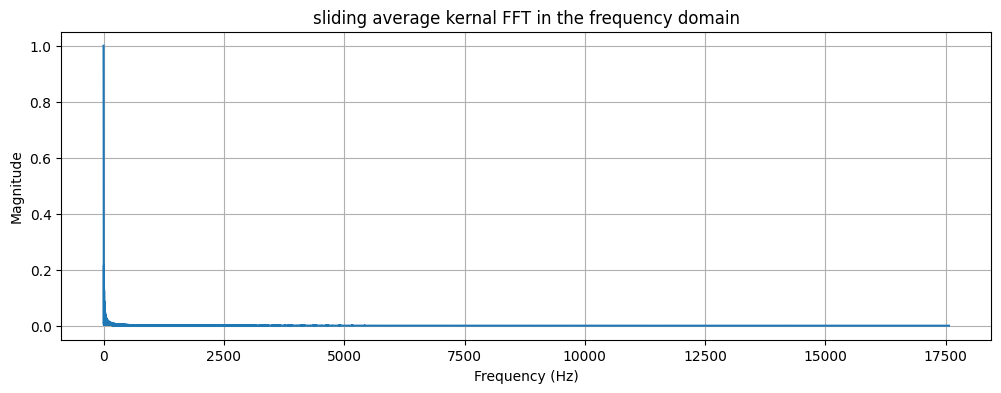

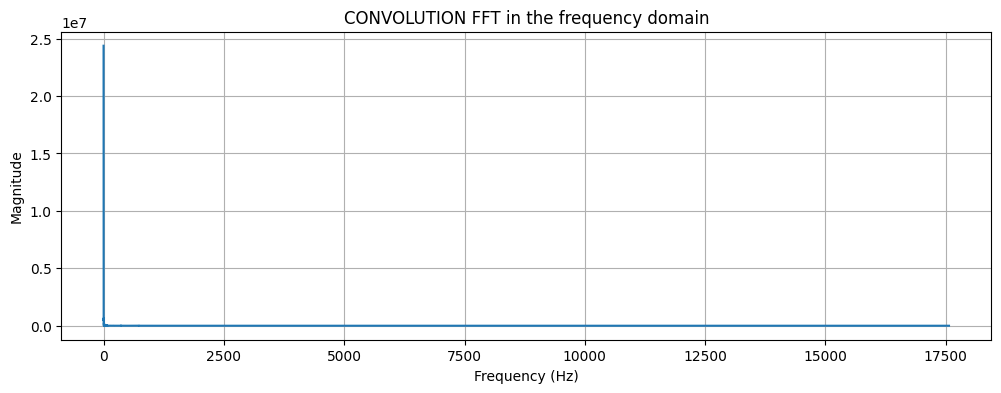

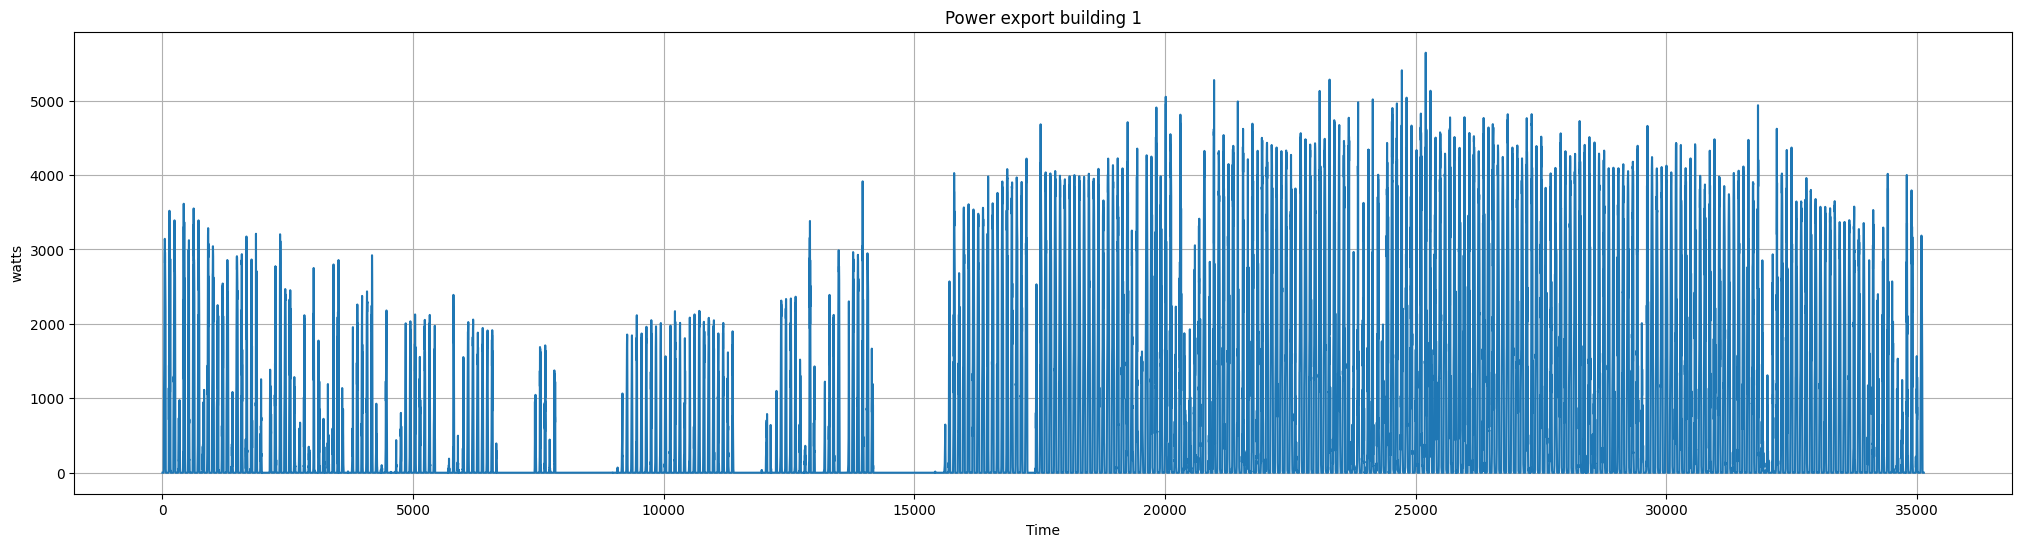

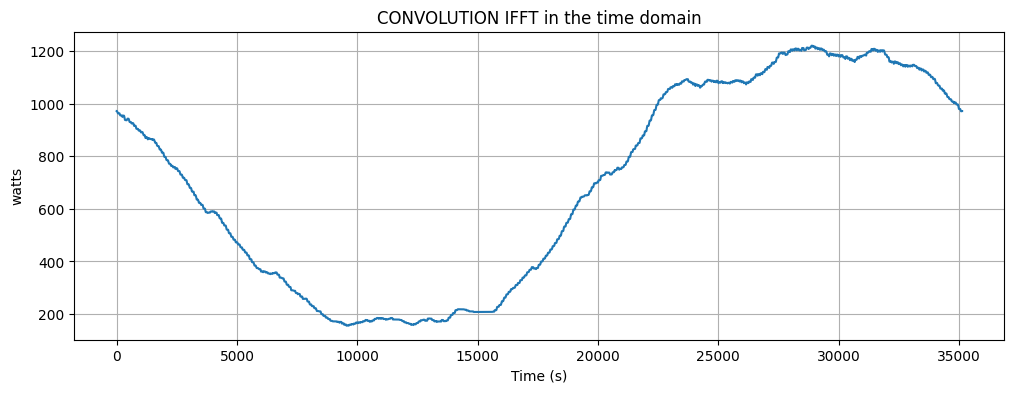

In [97]:
new_eb1 = []
for i in eb1:
    if math.isnan(i):
        new_eb1.append(0)
    else:
        new_eb1.append(i)

plt.figure(figsize=(25, 6))
plt.plot(new_eb1)
plt.xlabel("Time")
# plt.xticks(rotation='vertical')
plt.ylabel("watts")
plt.title("Power export building 1")
plt.grid()
# for x in range(0, len(ib1), 5400):
    # plt.axvline(x=x, color='gray', linestyle=':', linewidth=5)
plt.show()




fft_coeffs = np.fft.fft(new_eb1)
frequencies = range(len(new_eb1))

plt.figure(figsize=(12, 4))
plt.plot(frequencies[:len(frequencies)//2], np.abs(fft_coeffs)[:len(frequencies)//2], label="FFT Magnitude")
# plt.plot(frequencies, fft_coefs)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT in the signal domain")
plt.grid()
plt.show()

S = 7000
sliding_average = [1/S if(i >= 0 and i <= S-1) else 0 for i in range(len(eb1))]

plt.figure(figsize=(12, 4))
plt.plot(sliding_average)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("sliding average kernal in the time domain")
plt.grid()
plt.show()


sliding_fft_coeffs = np.fft.fft(sliding_average)

plt.figure(figsize=(12, 4))
plt.plot(frequencies[:len(frequencies)//2], np.abs(sliding_fft_coeffs)[:len(frequencies)//2], label="FFT Magnitude")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("sliding average kernal FFT in the frequency domain")
plt.grid()
plt.show()

convulution = fft_coeffs*sliding_fft_coeffs

plt.figure(figsize=(12, 4))
plt.plot(frequencies[:len(frequencies)//2], np.abs(convulution)[:len(frequencies)//2], label="FFT Magnitude")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("CONVOLUTION FFT in the frequency domain")
plt.grid()
plt.show()

ifft_convolution = np.fft.ifft(convulution)

plt.figure(figsize=(25, 6))
plt.plot(new_eb1)
plt.xlabel("Time")
# plt.xticks(rotation='vertical')
plt.ylabel("watts")
plt.title("Power export building 1")
plt.grid()
# for x in range(0, len(ib1), 5400):
    # plt.axvline(x=x, color='gray', linestyle=':', linewidth=5)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(ifft_convolution)
plt.xlabel("Time (s)")
plt.ylabel("watts")
plt.title("CONVOLUTION IFFT in the time domain")
plt.grid()
plt.show()

### Thresholding

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 245.48603351955308, 549.268156424581, 694.3575418994413, 811.55, 934.6166666666668, 1008.7653631284916, 1074.3798882681565, 1153.5474860335196, 1177.0558659217877, 1243.7166666666667, 1470.2234636871508, 1808.4277777777777, 2075.905555555556, 2207.8379888268155, 2591.31843575419, 2717.63687150838, 2772.8659217877093, 2893.161111111111, 2982.3944444444446, 3067.2166666666667, 3111.776536312849, 3139.016759776536, 3142.854748603352, 3129.424581005587, 3098.5666666666666, 2818.8268156424583, 2961.585635359116, 2888.2793296089385, 2846.2960893854747, 2742.972067039106, 2663.335195530726, 2612.527777777778, 2597.3611111111118, 2550.877094972067, 2417.150837988827, 2373.435754189944, 2197.027932960894, 1600.9497206703911, 968.3966480446928, 95.58100558659218, 150.50279329608938, 51.31843575418994, 19.10055865921788, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

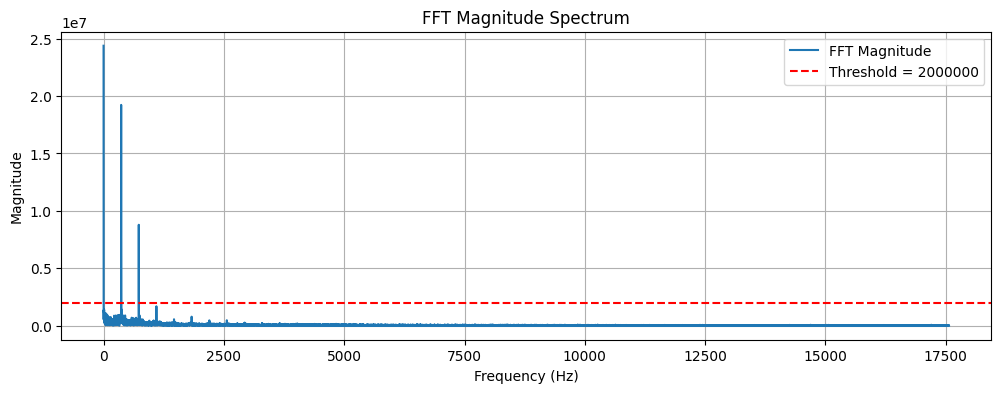

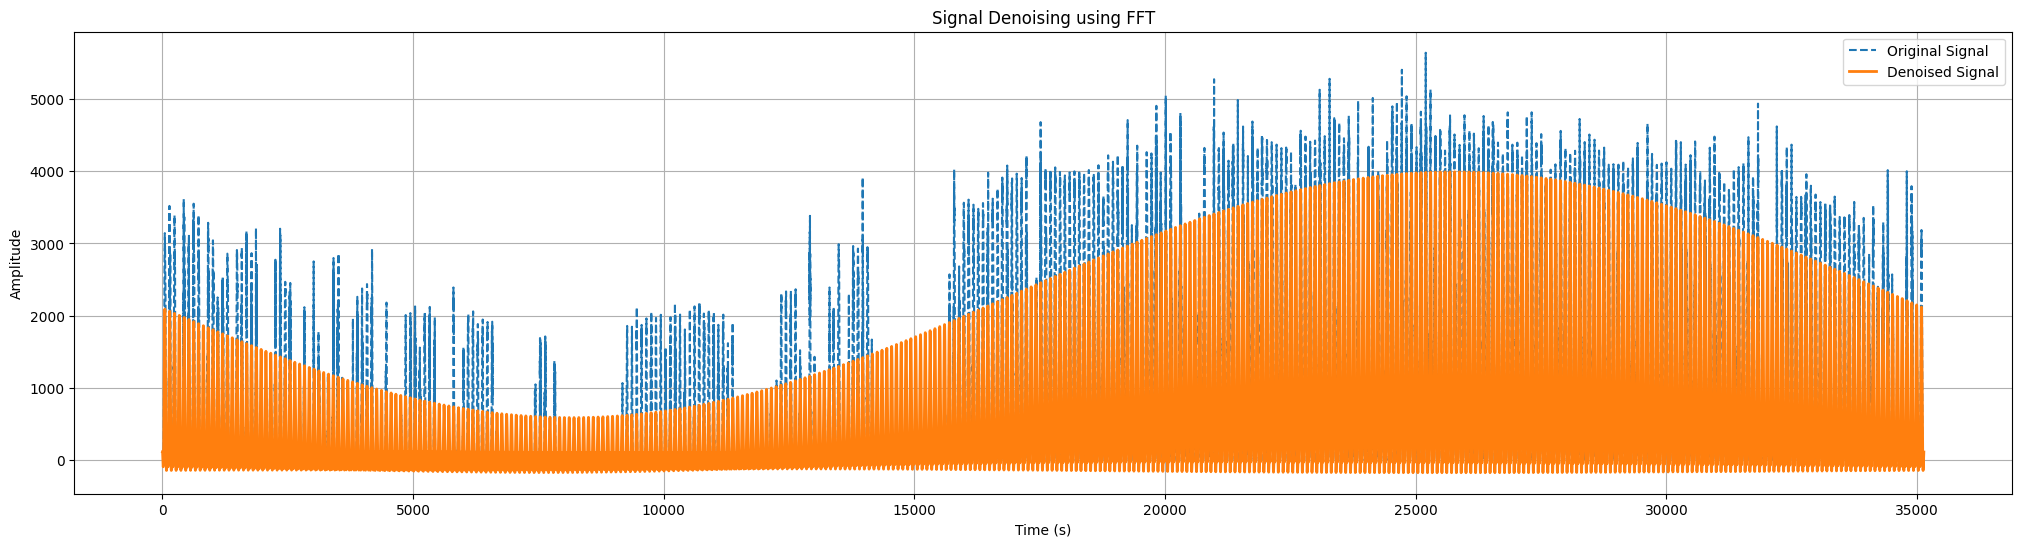

In [53]:
print(new_eb1)
fft_coeffs = np.fft.fft(new_eb1)
frequencies = range(len(eb1))
t = range(len(eb1))

threshold = 2000000

plt.figure(figsize=(12, 4))
plt.plot(frequencies[:len(frequencies)//2], np.abs(fft_coeffs)[:len(frequencies)//2], label="FFT Magnitude")
plt.axhline(y=threshold, color='r', linestyle='--', label=f"Threshold = {threshold}")  # Horizontal line
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT Magnitude Spectrum")
plt.legend()
plt.grid()
plt.show()

# Apply thresholding (keep only strong frequency components)
fft_coeffs_filtered = np.where(np.abs(fft_coeffs) > threshold, fft_coeffs, 0)

# Compute the inverse FFT
denoised_signal = np.fft.ifft(fft_coeffs_filtered) # COMPLETE HERE: COMPUTE THE INVERSE FOURIER TRANSFORM AND TAKE ITS REAL PART

# Plot original, noisy, and denoised signals
plt.figure(figsize=(25, 6))
plt.plot(t, eb1, label="Original Signal", linestyle="dashed")
plt.plot(t, denoised_signal, label="Denoised Signal", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Signal Denoising using FFT")
plt.legend()
plt.grid()
plt.show()

# Recap

#### 4. At how many different scale can we parse these data?
Day by day, half-day and hour are optimal. So three.

#### 5. What is the optimal scale at which I can study these data? Justify.
Hour by hour will be a good scale, as not much changes every 15minutes, so a larger scale is a better idea.
Day by day however removes all of the small details such as stops in the input or outputs.
Half day could be good but as we'll see in part 7./8./9., there are some variations in the stops.

#### 6.  How long have these data been acquired for?
As said before, close to 40hours so less than two days.

#### 7./8./9. When did the recording start (hint: at least identify the season)?
Building 1 seems to be pretty consistent with it's output and input of current, but it's output is far greater than it's input.\
It could be some sort of small powerplant, where it not only produces electricity there, but also acts as a hub, redistributing power from other plants.

Building 2 however hardly every outputed any current, so not a producer or provider. It does however consume 
a very large amount but only from midnight until about after midday.\
This building could be something like a heating provider because of the lack of energy use during the day, especially the afternoon where it's warmer.

Building 3 is similar to 2, where it stops from about 18h00 until midnight. However, it consumes a fair amount of power, but exports an enourmous amount. This could be a 


So the recording started at midnight, some time in the season of winter.

#### Prompt (ClaudAI):
me:
Hi would it be possible for you to put dotted vertical bars every 5400 iterations of x please ?


```python
ib1 = data["power import building 1 [watts]"]

plt.figure(figsize=(25, 6))
plt.plot(ib1)
plt.xlabel("Time")
# plt.xticks(rotation='vertical')
plt.ylabel("watts")
plt.title("Power input building 1")
plt.grid()
plt.show()
```


ClaudeAI:
```python
ib1 = data["power import building 1 [watts]"]

plt.figure(figsize=(25, 6))
plt.plot(ib1)
plt.xlabel("Time")
plt.ylabel("watts")
plt.title("Power input building 1")
plt.grid()

# Add dotted vertical bars every 5400 iterations
for x in range(0, len(ib1), 5400):
    plt.axvline(x=x, color='gray', linestyle=':', linewidth=1)

plt.show()
```

Just add a loop using plt.axvline after plt.grid(). Each line is drawn at multiples of 5400 along the x-axis. You can tweak color, linewidth, or linestyle (e.g. '--' for dashed) to your taste.